
# Desarrollo del Proyecto Final



Diplomado en Inteligencia Artificial & Aprendizaje Profundo

Presentado por: 

Luis Octavio González Salcedo



## 1. Introducción



En el presente cuardeno se desarrolla la ejecución del entrenamiento de una red neuronal de Mapas Auto-organizados (SOM), o red neuronal de Kohonen. Este entrenamiento se aplica para la estimación de la resistencia a compresión de diseño, para dosificaciones de mezclas de hormigón reforzado con fibras metálicas.

A manera de contexto general, se explica que en los hormigones además de la materia prima convencional, como el cemento, agua, arena y grava, se usan otro más buscando ganancia en sus propiedades, tanto en estado fresco (propiedades de manejo de la mezcla) como en estado endurecido (propiedades mecánicas y de durabilidad). El Autor de este documento, ha entrenado redes neuronales multicapas de Perceptrón (BackPropagation) y de Funciones de Base Radial. Para los fines de entrenamiento, el conjunto de entrenamiento se ha conformado con variables tanto cuantitativas como cualitativas; varias formas de expresar estar variables se han hecho, como por ejemplo las variables cuantitativas en términos absolutos o en relaciones entre varias de ellas, mientras que las variables cualitativas se han expresado en términos de variables de clase o jerarquizadas. Se ha comprobado que el conjunto de entrenamiento expresado en términos de relaciones entre los materiales (para las variables cualitativas) y en términos de variables jerarquizadas (para las variables cualitativas) han presentado mejores resultados en el entrenamiento de las redes neuronales artificiales. También, las redes neuronales de funciones de base radial han presentado mejores resultados en comparación con las redes de perceptrón multicapa.

Las redes neuronales artificiales mencionadas y entrenadas para la estimación de la resistencia a la compresión, son del tipo supervisado. Es de interés, entonces, probar otros modelos neuronales artificiales para dicho fin, principalmente de tipo no supervisado. En este caso, las redes neuronales de mapas auto-organizados o de Kohonen, pueden ser aplicadas, para determinar clases de resistencias. En este cuaderno, se presenta entonces, el entrenamiento de una red neuronal de Kohonen para la estimación de la resistencia a compresión de diseño del hormigón reforzado con fibra. Es importante aclarar, que en este caso, el entrenamiento se realiza para explorar la capacidad de clasificar estas dosificaciones en clases de resistencia (o rangos o intervalos de consistencia). Se procederá a dos entrenamiento, una con un conjunto de entrenamiento que incluye el valor de la resistencia y otro que no la incluye, con el fin de comparar los resultados en el mapeo, que permita inferir para estos resultados si el modelo neuronal tiene la capacidad de hacer una clasificación correcta para esta aplicación en particular. Para ambos casos el etiquetado, con fines de evaluar la capacidad, se hace en ambos conjuntos de entrenamiento.



## 2. Importación de Índices

Para el desarrollo adecuado del lenguaje de programación se realiza la importación requerida para este tipo de problemas a ejecutar:


In [1]:

##Importación de librerías y funciones requeridas:

import tensorflow as tf ##importación de tensorflow

import pathlib ##importación del módulo pathlib
import os ##importación del módulo os
import matplotlib.pyplot as plt ##importación de matplotlib
import pandas as pd ##importación de pandas
import numpy as np ##importación de numpy

##configura las opciones de impresión
##Estas opciones determinan la forma en que se muestran los números de punto flotante, las matrices y otros objetos NumPy.
##En este caso, usa el parámetro de precisión, que corresponde al número de dígitos de precisión para salida de punto flotante.
np.set_printoptions(precision=4)


from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing


##Importaciones Adicionales:
import seaborn as sns ##Importar librería para la visualización de datos estadisticos
import sklearn
sklearn.show_versions()
import sklearn.preprocessing ##Importar librería para pre-procesar datos

##Importación de LabelEncoder()
from sklearn.preprocessing import LabelEncoder



System:
    python: 3.8.5 (default, Sep  3 2020, 21:29:08) [MSC v.1916 64 bit (AMD64)]
executable: C:\Users\Usuario\anaconda3\python.exe
   machine: Windows-10-10.0.19041-SP0

Python dependencies:
          pip: 21.0.1
   setuptools: 52.0.0.post20210125
      sklearn: 0.24.2
        numpy: 1.20.1
        scipy: 1.6.2
       Cython: 0.29.23
       pandas: 1.2.4
   matplotlib: 3.3.4
       joblib: 1.0.1
threadpoolctl: 2.1.0

Built with OpenMP: True



Importaciones relacionadas con SOM:


In [2]:

from minisom import MiniSom 

import sys
sys.path.insert(0, '../')
%load_ext autoreload

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline

from minisom import MiniSom
from sklearn.preprocessing import minmax_scale, scale
%autoreload 2


Finalmente, se visualiza el directorio de trabajo:


In [3]:

os.getcwd() ##Se visualiza donde está ubicado el directorio de trabajo


'C:\\Users\\Usuario\\Desktop\\luis octavio gonzalez\\Curso DIplomado IA & AP\\Repositorio Curso\\Diplomado\\Temas\\Fundamentos\\Cuadernos'


## 3. Conjunto de Datos




La base de datos tomada para el desarrollo del proyecto, corresponde a la almacenada en el archivo base_datos_mezclas.csv. Este conjunto de datos contiene reportes de diseños de mezclas (dosificaciones de mezclas) de hormigón. Las mezclas de hormigón allí reportadas han sido recopiladas de reportes consultados en artículos de revistas, documentos finales de trabajos de grado y tesis, e informes técnicos. Los reportes incluyen diseños de mezlcas de hormigón que no incluyen e incluyen fibras de acero, como material reforzante de la matriz cementicia.

Cada registro del conjunto de datos, originalmente reporta el tipo y cantidad de los materiales utilizados, y en algunos casos la clase o calidad del tipo de material. El conjunto de datos del proyecto, se elaboró a partir no solo de las cantidades sino también a partir de diversas relaciones de los materiales, en razón a que experiencias previas de entrenamiento de redes neuronales artificiales (redes multicapas de backpropagation) mostraron mejores resultados en estas redes y en otras (redes de funciones de base radial) cuando el conjunto de entrenamiento se presentó de esta manera, y donde las variables cualitativas se representaron de manera jerárquica [1](https://www.redalyc.org/jatsRepo/911/91163366005/91163366005.pdf).

El conjunto de datos contiene valores para las siguientes variables (El conjunto de datos se ha conformado con 626 registros, cuyas variables son: "No.", "C_Kg/m3", "C-1", "C-2", "C-3", "C-4", "SF/binder", "FA/binder", "GBFS/binder", "puzolana/binder", "(W+HWR)/binder", "HWR/binder", HWR-P", "HWR-SP", "(W+HWR)/sólidos", "S/(S+G)", "T-S", "(S+G)/binder)", "T-G", "G-TMA_mm", "LTCA", "AEA/binder", "Vf", "T-SFR", "Lf_mm", "Lf/Df", "fc_MPa"), que se describen a continuación (las unidades para cantidades se expresan con relación a un metro cúbico de hormigón elaborado):




No., corresponde al número de registro (no está explícito en el conjunto de datos, sin embargo, en la carga del archivo e impresión, la tabla lo muestra).

C_Kg/m3, corresponde a la cantidad de cemento, y se expresa en Kg/m^3

C-1, corresponde a uso de cemento de uso general (Tipo I)

C-2, corresponde a uso de cemento para acción moderada al sulfato y calor moderado a la hidratación, y bajo calor a la hidratación (Tipo II y Tipo IV, respectivamente)

C-3, corresponde a uso de cemento para resistencia altas a temprana edad (Tipo III)

C-4, corresponde a uso de cemento para alta resistencia a los sulfatos (Tipo V)

SF/binder, corresponde a la relación (cantidad de humo de sílice) / (cantidad de material cementante)

FA/binder, corresponde a la relación (cantidad de cenizas volante) / (cantidad de material cementante)

GBFS/binder, corresponde a la relación (cantidad escorias) / (cantidad de material cementante)

puzolana/binder, corresponde a la relación (cantidad de material puzolánico) / (cantidad de material cementante)

(W+HWR)/binder, corresponde a la relación (cantidades de de agua y agente retenedor de agua) /(cantidad de material cementante)

HWR/binder, corresponde a la relación (cantidad de agente renetedor de agua) / (cantidad de material cementante)

HWR-P, corresponde a uso de agente retenedor de agua tipo plastificante

HWR-SP, corresponde a uso de agente retenedor de agua tipo superplastificante

(W+HWR)/sólidos, corresponde a la relación (cantidades de agua y agente retenedor de agua) / (cantidad de material sólido)

S/(S+G), corresponde a la relación (cantidad de agregado fino) / (cantidad de agregados)

T-S, corresponde al origen de extracción del agregado fino

(S+G)/binder), corresponde a la relación (cantidad de agregado) / (cantidad de material cementante)

T-G, corresponde al origen de extracción del agregado grueso

G-TMA_mm, corresponde al tamaño máximo del agregado grueso, expresado en mm

LTCA, corresponde al tipo de perfil litológico del agregado grueso, es decir origen geológico

AEA/binder, corresponde a la relación (cantidad de agente entrador de aire) /(cantidad de material cementante)

Vf, corresponde a la cantidad de fibra metálica, expresada en fracción de volumen

T-SFR, corresponde al tipo de fibra metálica

Lf_mm, corresponde a la longitud de la fibra metálica

Lf/Df, corresponde a la relación de aspecto de la fibra, lo cual es la relación entre su longitud y su diámetro equivalente

fc_MPa, corresponde a la resistencia de diseño a la compresión, del hormigón en estado endurecido, y obtenido a partir de una dosificación de materia prima consistente en cemento, agua, humo de sílice, cenizas volantes, escoria, arena, grava, agente retenedor de agua, agente inclusor de aire, y fibra metálica, así como algunos atributos de la materia prima. Esta variable se expresa en MPa.



A continuación se carga el conjunto de datos:


In [4]:

##Se carga el conjunto de datos en la variable D
D = 'base_datos_mezclas.csv'
data = pd.read_csv(D, header=0, sep=';')
print(data.shape)
data.head()


(626, 26)


,C_Kg/m3,C-1,C-2,C-3,C-4,SF/ binder,FA/binder,GBFS/binder,puzolana/binder,(W+HWR)/binder,...,(S+G)/binder,T-G,G-TMA_mm,LTCA,AEA/binder,Vf,T-SFR,Lf_mm,Lf/Df,fc_MPa
0,308.40,1,0,0,0,0.0,0.200,0.0,0.200,0.4500,...,8.4047,1.0,10.0,1.0,0.0,0.00,0.0,0.0,0.0,15.56
1,318.04,1,0,0,0,0.0,0.175,0.0,0.175,0.4638,...,8.4047,1.0,10.0,1.0,0.0,0.00,0.0,0.0,0.0,16.44
2,308.40,1,0,0,0,0.0,0.200,0.0,0.200,0.4500,...,8.4047,1.0,10.0,1.0,0.0,0.25,1.0,30.0,50.0,16.44
3,308.40,1,0,0,0,0.0,0.200,0.0,0.200,0.4500,...,8.4047,1.0,10.0,1.0,0.0,0.50,1.0,30.0,50.0,16.44
4,308.40,1,0,0,0,0.0,0.200,0.0,0.200,0.4500,...,8.4047,1.0,10.0,1.0,0.0,0.75,1.0,30.0,50.0,16.89



Este conjunto de datos se modificará para evaluar el uso de mapas auto-organizados en dos nuevos conjuntos de datos, a saber: Un primer conjunto que conserva la última columna correspondiente a la resistencia a la compresión, y un segundo conjunto el cual no contiene esta columna. Para ambos casos, se ha etiquetado en rangos de resistencias, siendo la primera clase para las dosificaciones de mezclas que dieron como resultado una resistencia menor a 21 MPa (generalmente, este valor es el que corresponde a un hormigón de uso general en la construcción, siendo por debajo de 21 MPa, hormigones de baja resistencia) y la última clasificación corresponde a hormigones de muy alta resistencia para lo cual se toman resistencias por encima de 100 MPa. Cada rango intermedio se ha tomado cada 10 MPa, conformado las siguientes clases:



(los limites superiores no son incluidos)

Clase 1: menores a 21 MPa

Clase 2: 21-30 MPa

Clase 3: 30-40 MPa

Clase 4: 40-50 MPa

Clase 5: 50-60 Mpa

Clase 6: 60-70 Mpa

Clase 7: 70-80 MPa

Clase 8: 80-90 MPa

Clase 9: 90 - 100 MPa

Clase 10: mayores a 100 MPa



A continuación se procede al estudio de cada caso.



## 4. Estudio de Caso 1



### 4.1. Conjunto de Datos


In [5]:

##Se carga el conjunto de datos en la variable E y se almacena en data1
E = 'base_datos_mezclas1.csv'
data1 = pd.read_csv(E, header=0, sep=';')
print(data1.shape)
data1.head()

(626, 27)


,C_Kg/m3,C-1,C-2,C-3,C-4,SF/ binder,FA/binder,GBFS/binder,puzolana/binder,(W+HWR)/binder,...,T-G,G-TMA_mm,LTCA,AEA/binder,Vf,T-SFR,Lf_mm,Lf/Df,fc_MPa,Clase
0,308.40,1,0,0,0,0.0,0.200,0.0,0.200,0.4500,...,1.0,10.0,1.0,0.0,0.00,0.0,0.0,0.0,15.56,1
1,318.04,1,0,0,0,0.0,0.175,0.0,0.175,0.4638,...,1.0,10.0,1.0,0.0,0.00,0.0,0.0,0.0,16.44,1
2,308.40,1,0,0,0,0.0,0.200,0.0,0.200,0.4500,...,1.0,10.0,1.0,0.0,0.25,1.0,30.0,50.0,16.44,1
3,308.40,1,0,0,0,0.0,0.200,0.0,0.200,0.4500,...,1.0,10.0,1.0,0.0,0.50,1.0,30.0,50.0,16.44,1
4,308.40,1,0,0,0,0.0,0.200,0.0,0.200,0.4500,...,1.0,10.0,1.0,0.0,0.75,1.0,30.0,50.0,16.89,1



Se procede a separar las variables independientes para generar las matriz de características (X) de la última columna que corresponde al vector de las etiquetas (Y1):


In [6]:

np.set_printoptions(precision=4)

##Creación de la matriz X de características:
X = data1.iloc[:, :-1].values

##Creación del vector de las etiquetas:
Y1 = data1.iloc[:, -1].values


In [7]:

##Impresión de la matriz X de características:

print(X.shape)
print(X)


(626, 26)
[[308.4    1.     0.   ...   0.     0.    15.56]
 [318.04   1.     0.   ...   0.     0.    16.44]
 [308.4    1.     0.   ...  30.    50.    16.44]
 ...
 [677.     1.     0.   ...  16.    89.   192.5 ]
 [677.     1.     0.   ...   6.    33.   197.  ]
 [677.     1.     0.   ...   6.    33.   200.5 ]]


In [8]:

##Impresipon del vector Y1 de etiquetas:
print(Y1.shape)
print(Y1)


(626,)
[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  


Se procede a eliminar una serie de columnas, con el fin de dejar columnas que se consideran como las variables características (se eliminarán las columnas: 1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 15, 17, 20, 22, 23, 24. Este procedimiento se hará sobre la matriz X:


In [9]:

from numpy import genfromtxt,array,linalg,zeros,apply_along_axis

##Generación de la matriz de características relevantes X1, a partir de eliminación de columnas de X:

X1 = np.delete(X, (1, 2, 3, 4, 5, 6, 7, 10, 11, 12, 15, 17, 20, 22, 23, 24), axis=1)
print(X1.shape)
print(X1)


(626, 10)
[[3.0840e+02 2.0000e-01 4.5000e-01 ... 1.0000e+00 0.0000e+00 1.5560e+01]
 [3.1804e+02 1.7500e-01 4.6380e-01 ... 1.0000e+00 0.0000e+00 1.6440e+01]
 [3.0840e+02 2.0000e-01 4.5000e-01 ... 1.0000e+00 2.5000e-01 1.6440e+01]
 ...
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 3.3000e-01 8.9000e-01 1.9250e+02]
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 3.3000e-01 8.9000e-01 1.9700e+02]
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 3.3000e-01 2.2300e+00 2.0050e+02]]


In [10]:

import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom 


In [11]:

import sys
sys.path.insert(0, '../')
%load_ext autoreload

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline

from minisom import MiniSom
from sklearn.preprocessing import minmax_scale, scale
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



También puede realizarse el cargue usando las siguientes instrucciones. El fragmento de abajo lee el conjunto de datos almacenado en un archivo CSV, en este caso el archivo base_datos_mezclas1.csv, y crea una matriz donde cada fila corresponde a un patrón. En este caso, Se tiene que cada patrón tendrá 10 dimensiones (en las columnas: 0, 8, 9, 13, 14, 16, 18, 19, 21, 25). Se tiene en cuentra que la última columna del archivo, es decir la de la posición 26 contiene las etiquetas:


In [12]:

##Se determinan que columnas se usarán para las características y se excluye la última columna de las etiquetas:
data1 = genfromtxt('base_datos_mezclas1.csv', delimiter=';',usecols=(0,8,9,13,14,16,18,19,21,25))


In [13]:

print(data1.shape)
print(data1)


(627, 10)
[[       nan        nan        nan ...        nan        nan        nan]
 [3.0840e+02 2.0000e-01 4.5000e-01 ... 1.0000e+00 0.0000e+00 1.5560e+01]
 [3.1804e+02 1.7500e-01 4.6380e-01 ... 1.0000e+00 0.0000e+00 1.6440e+01]
 ...
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 3.3000e-01 8.9000e-01 1.9250e+02]
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 3.3000e-01 8.9000e-01 1.9700e+02]
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 3.3000e-01 2.2300e+00 2.0050e+02]]


In [14]:

##Eliminación de la primera fila:
data1 = np.delete(data1, 0, axis=0)


In [15]:

print(data1.shape)
print(data1)


(626, 10)
[[3.0840e+02 2.0000e-01 4.5000e-01 ... 1.0000e+00 0.0000e+00 1.5560e+01]
 [3.1804e+02 1.7500e-01 4.6380e-01 ... 1.0000e+00 0.0000e+00 1.6440e+01]
 [3.0840e+02 2.0000e-01 4.5000e-01 ... 1.0000e+00 2.5000e-01 1.6440e+01]
 ...
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 3.3000e-01 8.9000e-01 1.9250e+02]
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 3.3000e-01 8.9000e-01 1.9700e+02]
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 3.3000e-01 2.2300e+00 2.0050e+02]]



Los datos se normalizan:


In [16]:

##normalización a la unidad para cada patrón en el data1
data1 = apply_along_axis(lambda x: x/linalg.norm(x),1,data1)


In [17]:

##Impresión del conjunto data1 normalizado
print(data1.shape)
print(data1)


(626, 10)
[[9.9783e-01 6.4710e-04 1.4560e-03 ... 3.2355e-03 0.0000e+00 5.0344e-02]
 [9.9782e-01 5.4905e-04 1.4551e-03 ... 3.1374e-03 0.0000e+00 5.1579e-02]
 [9.9768e-01 6.4701e-04 1.4558e-03 ... 3.2350e-03 8.0876e-04 5.3184e-02]
 ...
 [9.6185e-01 2.8387e-04 2.8387e-04 ... 4.6885e-04 1.2645e-03 2.7349e-01]
 [9.6015e-01 2.8336e-04 2.8336e-04 ... 4.6802e-04 1.2622e-03 2.7939e-01]
 [9.5880e-01 2.8297e-04 2.8297e-04 ... 4.6736e-04 3.1582e-03 2.8396e-01]]



### 4.2. Entrenamiento y generación del SOM



El proceso de entrenamiento se puede iniciar. Se va a generar un SOM de tamaño size x size, que estará capacitado en el conjunto de datos (data1). MiniSom usa una función de vecindad gaussiana y su propagación inicial se especifica con el parámetro sigma. Mientras que con el parámetro learning_rate se puede especificar la tasa de aprendizaje inicial. El algoritmo de entrenamiento implementado disminuye ambos parámetros a medida que avanza el entrenamiento. Esto permite un entrenamiento inicial rápido de la red neuronal que luego se "ajusta" a medida que avanza el entrenamiento.


In [18]:

from minisom import MiniSom

##Inicialización y Entrenamiento:

size = 15
som = MiniSom(size,size,len(data1[0]),neighborhood_function='gaussian',sigma=0.1,learning_rate=0.3)
som.random_weights_init(data1)
print("Training...")

##Entrenamiento con 100 iteraciones:
som.train_random(data1,100)
print("\n...ready!")


Training...

...ready!



Para visualizar el resultado del entrenamiento, se puede trazar el mapa de distancia promedio de los pesos en el mapa y las coordenadas de la neurona ganadora asociada para cada patrón:


(626,)
[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  

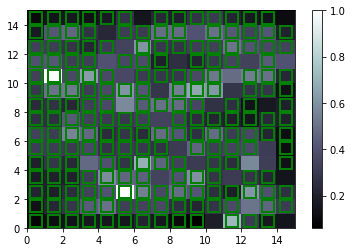

In [19]:

from pylab import plot,axis,show,pcolor,colorbar,bone
bone()

##Mapa de distancia como fondo:
pcolor(som.distance_map().T)
colorbar()

##Cargando las etiquetas:
target = genfromtxt('base_datos_mezclas1.csv', delimiter=';',usecols=(26),dtype=int)
target = np.delete(target, 0, axis=0)

t = zeros(len(target),dtype=int)
t[target == 1] = 1
t[target == 2] = 2
t[target == 3] = 3
t[target == 4] = 4
t[target == 5] = 5
t[target == 6] = 6
t[target == 7] = 7
t[target == 8] = 8
t[target == 9] = 9
t[target == 10] = 10

print(target.shape)
print(target)

print(t.shape)
print(t)

##Uso de diferentes marcadores y colores para cada etiqueta
markers = ['o','s','D','p','v','*','<','>','+','x']
colors = ['r','g','b','c','m','y','k','w','orange','purple']

for cnt,xx in enumerate(data1):
    ##Consiguiendo el ganador:
    w = som.winner(xx)
    ##Colocación de un marcador dentro de la posición ganadora de la muestra xx:
    plot(w[0]+.5,w[1]+.5,markers[t[cnt%10]],markerfacecolor='None',markeredgecolor=colors[t[cnt%10]],markersize=12,markeredgewidth=2)
axis([0,som._weights.shape[0],0,som._weights.shape[1]])
show() # show the figure



## 5. Estudio de Caso 2



### 5.1. Conjunto de Datos



Se realiza el cargue usando las siguientes instrucciones. El fragmento de abajo lee el conjunto de datos almacenado en un archivo CSV, en este caso el archivo base_datos_mezclas2.csv, y crea una matriz donde cada fila corresponde a un patrón. En este caso, Se tiene que cada patrón tendrá 9 dimensiones (en las columnas: 0, 8, 9, 13, 14, 16, 18, 19, 21). Se tiene en cuentra que la última columna del archivo, es decir la de la posición 25 contiene las etiquetas:


In [20]:

##Se determinan que columnas se usarán para las características y se excluye la última columna de las etiquetas:
data2 = genfromtxt('base_datos_mezclas2.csv', delimiter=';',usecols=(0,8,9,13,14,16,18,19,21))


In [21]:

##Eliminación de la primera fila:
data2 = np.delete(data2, 0, axis=0)


In [22]:

print(data2.shape)
print(data2)


(626, 9)
[[3.0840e+02 2.0000e-01 4.5000e-01 ... 1.0000e+01 1.0000e+00 0.0000e+00]
 [3.1804e+02 1.7500e-01 4.6380e-01 ... 1.0000e+01 1.0000e+00 0.0000e+00]
 [3.0840e+02 2.0000e-01 4.5000e-01 ... 1.0000e+01 1.0000e+00 2.5000e-01]
 ...
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 4.7500e+00 3.3000e-01 8.9000e-01]
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 4.7500e+00 3.3000e-01 8.9000e-01]
 [6.7700e+02 1.9980e-01 1.9980e-01 ... 4.7500e+00 3.3000e-01 2.2300e+00]]



Los datos se normalizan:


In [23]:

##normalización a la unidad para cada patrón en el data1
data2 = apply_along_axis(lambda x: x/linalg.norm(x),1,data2)


In [24]:

##Impresión del conjunto data1 normalizado
print(data2.shape)
print(data2)


(626, 9)
[[9.9910e-01 6.4792e-04 1.4578e-03 ... 3.2396e-02 3.2396e-03 0.0000e+00]
 [9.9915e-01 5.4978e-04 1.4571e-03 ... 3.1416e-02 3.1416e-03 0.0000e+00]
 [9.9910e-01 6.4792e-04 1.4578e-03 ... 3.2396e-02 3.2396e-03 8.0990e-04]
 ...
 [9.9997e-01 2.9512e-04 2.9512e-04 ... 7.0160e-03 4.8743e-04 1.3146e-03]
 [9.9997e-01 2.9512e-04 2.9512e-04 ... 7.0160e-03 4.8743e-04 1.3146e-03]
 [9.9997e-01 2.9512e-04 2.9512e-04 ... 7.0160e-03 4.8743e-04 3.2938e-03]]



### 5.2. Entrenamiento y generación del SOM



El proceso de entrenamiento se puede iniciar. Se va a generar un SOM de tamaño size x size, que estará capacitado en el conjunto de datos (data1). MiniSom usa una función de vecindad gaussiana y su propagación inicial se especifica con el parámetro sigma. Mientras que con el parámetro learning_rate se puede especificar la tasa de aprendizaje inicial. El algoritmo de entrenamiento implementado disminuye ambos parámetros a medida que avanza el entrenamiento. Esto permite un entrenamiento inicial rápido de la red neuronal que luego se "ajusta" a medida que avanza el entrenamiento.


In [25]:

from minisom import MiniSom

##Inicialización y Entrenamiento:

size = 15
som = MiniSom(size,size,len(data2[0]),neighborhood_function='gaussian',sigma=0.1,learning_rate=0.3)
som.random_weights_init(data2)
print("Training...")

##Entrenamiento con 100 iteraciones:
som.train_random(data2,100)
print("\n...ready!")


Training...

...ready!



Para visualizar el resultado del entrenamiento, se puede trazar el mapa de distancia promedio de los pesos en el mapa y las coordenadas de la neurona ganadora asociada para cada patrón:


(626,)
[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  2  2  2  2  2  2  2  2
  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3  3
  3  3  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4  4
  4  4  4  4  4  4  4  4  4  4  4  4  4  4  

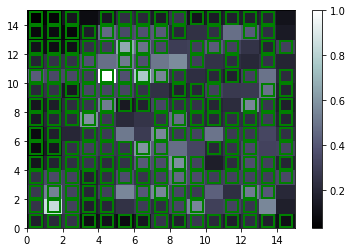

In [26]:

from pylab import plot,axis,show,pcolor,colorbar,bone
bone()

##Mapa de distancia como fondo:
pcolor(som.distance_map().T)
colorbar()

##Cargando las etiquetas:
target = genfromtxt('base_datos_mezclas2.csv', delimiter=';',usecols=(25),dtype=int)
target = np.delete(target, 0, axis=0)

t = zeros(len(target),dtype=int)
t[target == 1] = 1
t[target == 2] = 2
t[target == 3] = 3
t[target == 4] = 4
t[target == 5] = 5
t[target == 6] = 6
t[target == 7] = 7
t[target == 8] = 8
t[target == 9] = 9
t[target == 10] = 10

print(target.shape)
print(target)

print(t.shape)
print(t)

##Uso de diferentes marcadores y colores para cada etiqueta
markers = ['o','s','D','p','v','*','<','>','+','x']
colors = ['r','g','b','c','m','y','k','w','orange','purple']

for cnt,xx in enumerate(data2):
    ##Consiguiendo el ganador:
    w = som.winner(xx)
    ##Colocación de un marcador dentro de la posición ganadora de la muestra xx:
    plot(w[0]+.5,w[1]+.5,markers[t[cnt%10]],markerfacecolor='None',markeredgecolor=colors[t[cnt%10]],markersize=12,markeredgewidth=2)
axis([0,som._weights.shape[0],0,som._weights.shape[1]])
show() # show the figure
